# Taller: Predicción de satisfacción laboral con redes neuronales (Keras)
---

## Objetivo del taller

Desarrollar un modelo de red neuronal en Keras que prediga si un empleado está satisfecho o insatisfecho con su trabajo, a partir de variables demográficas y laborales.

### Actividades:

- Cargar y explorar el dataset.

- Preprocesar los datos.

- Entrenar una red neuronal con Keras.

- Evaluar el desempeño del modelo (accuracy, loss, matriz de confusión).

- Proponer y probar mejoras de desempeño (BatchNorm, Dropout, EarlyStopping, etc.).

- Redactar un breve informe del caso de negocio.

## Dataset - `employee_satisfaction.csv`

| **Columna**              | **Descripción**                                                                 |
|---------------------------|---------------------------------------------------------------------------------|
| `Age`                    | Edad del empleado                                                               |
| `Department`              | Departamento en el que trabaja                                                  |
| `Salary`                 | Salario mensual en dólares                                                      |
| `YearsAtCompany`         | Años trabajando en la empresa                                                   |
| `WorkLifeBalance`        | Valor entre 1 y 5 (percepción del equilibrio vida-trabajo)                      |
| `JobInvolvement`         | Nivel de involucramiento en el trabajo (1 a 5)                                  |
| `PerformanceRating`      | Evaluación del desempeño anual (1 a 5)                                          |
| `TrainingTimesLastYear`  | Número de cursos de capacitación realizados                                     |
| `Satisfaction`           | **Variable objetivo:** 1 = Satisfecho / 0 = Insatisfecho   

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
path = '/content/drive/MyDrive/Colab aprendizaje supervisado/Taller 3/employee_satisfaction.csv'
df= pd.read_csv(path)

## Revisión de Dataset

In [18]:
print("Primeras filas:")
df.head()

Primeras filas:


,Age,Department,Salary,YearsAtCompany,WorkLifeBalance,JobInvolvement,PerformanceRating,TrainingTimesLastYear,Satisfaction
0,50,Finance,4865,18,3,5,2,3,0
1,36,HR,4764,14,4,1,3,0,1
2,29,Finance,4773,3,1,2,4,2,0
3,42,Finance,2844,11,5,4,4,4,1
4,40,Marketing,3763,5,4,1,2,2,0


In [19]:
print("\nInfo del dataset:")
df.info()


Info del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Age                    1000 non-null   int64 
 1   Department             1000 non-null   object
 2   Salary                 1000 non-null   int64 
 3   YearsAtCompany         1000 non-null   int64 
 4   WorkLifeBalance        1000 non-null   int64 
 5   JobInvolvement         1000 non-null   int64 
 6   PerformanceRating      1000 non-null   int64 
 7   TrainingTimesLastYear  1000 non-null   int64 
 8   Satisfaction           1000 non-null   int64 
dtypes: int64(8), object(1)
memory usage: 70.4+ KB


In [20]:
print("\nEstadísticas:")
df.describe()


Estadísticas:


,Age,Salary,YearsAtCompany,WorkLifeBalance,JobInvolvement,PerformanceRating,TrainingTimesLastYear,Satisfaction
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,40.947000,4021.429000,9.877000,3.055000,2.982000,3.468000,1.942000,0.432000
std,11.160858,978.390279,5.756649,1.399977,1.431686,1.102811,1.402356,0.495602
min,22.000000,648.000000,0.000000,1.000000,1.000000,2.000000,0.000000,0.000000
25%,31.000000,3344.750000,5.000000,2.000000,2.000000,3.000000,1.000000,0.000000
50%,42.000000,4045.000000,10.000000,3.000000,3.000000,3.000000,2.000000,0.000000
75%,50.000000,4686.250000,15.000000,4.000000,4.000000,4.000000,3.000000,1.000000
max,59.000000,7495.000000,19.000000,5.000000,5.000000,5.000000,4.000000,1.000000


In [21]:
print("\nDistribución de la variable objetivo:")
df['Satisfaction'].value_counts()


Distribución de la variable objetivo:


,count
Satisfaction,
0,568
1,432


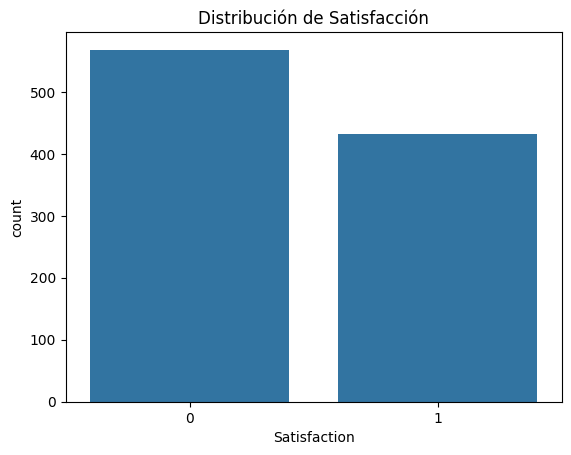

In [22]:
# Visualización básica
sns.countplot(x='Satisfaction', data=df)
plt.title('Distribución de Satisfacción')
plt.show()

In [14]:
# Display the count of each unique value in the 'Department' column
print("Value counts for the 'Department' column:")
display(df['Department'].value_counts())

Value counts for the 'Department' column:


,count
Department,
IT,214
Finance,207
HR,198
Sales,194
Marketing,187


In [23]:
# Count the number of outliers per variable
outlier_counts = ((numerical_df < lower_bound) | (numerical_df > upper_bound)).sum()

print("Number of outliers per variable (based on IQR):")
display(outlier_counts)

Number of outliers per variable (based on IQR):


,0
Age,0
Salary,5
YearsAtCompany,0
WorkLifeBalance,0
JobInvolvement,0
PerformanceRating,0
TrainingTimesLastYear,0
Satisfaction,0


## Preprocesamiento

In [24]:
# Remover outliers
df_cleaned = df[~((numerical_df < lower_bound) | (numerical_df > upper_bound)).any(axis=1)]

print("Shape of DataFrame after removing outliers:")
display(df_cleaned.shape)

Shape of DataFrame after removing outliers:


(995, 9)

First few rows of the cleaned DataFrame:


,Age,Department,Salary,YearsAtCompany,WorkLifeBalance,JobInvolvement,PerformanceRating,TrainingTimesLastYear,Satisfaction
0,50,Finance,4865,18,3,5,2,3,0
1,36,HR,4764,14,4,1,3,0,1
2,29,Finance,4773,3,1,2,4,2,0
3,42,Finance,2844,11,5,4,4,4,1
4,40,Marketing,3763,5,4,1,2,2,0


In [25]:
# Codificar categóricos
le = LabelEncoder()
df_cleaned['Department'] = le.fit_transform(df_cleaned['Department'])


/tmp/ipython-input-3925590338.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Department'] = le.fit_transform(df_cleaned['Department'])


In [28]:
# Normalizar numéricos
scaler = StandardScaler()
numerical_cols = ['Age', 'Salary', 'YearsAtCompany', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating', 'TrainingTimesLastYear']
df_cleaned[numerical_cols] = scaler.fit_transform(df_cleaned[numerical_cols])

/tmp/ipython-input-2299270083.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[numerical_cols] = scaler.fit_transform(df_cleaned[numerical_cols])


In [29]:
df_cleaned.head()

,Age,Department,Salary,YearsAtCompany,WorkLifeBalance,JobInvolvement,PerformanceRating,TrainingTimesLastYear,Satisfaction
0,0.808637,0,0.879279,1.407796,-0.040945,1.407404,-1.333631,0.752883,0
1,-0.445881,1,0.773638,0.712545,0.673793,-1.384953,-0.425996,-1.389497,1
2,-1.073140,0,0.783052,-1.199396,-1.470420,-0.686864,0.481640,0.038757,0
3,0.091770,0,-1.234586,0.191107,1.388530,0.709315,0.481640,1.467010,1
4,-0.087447,3,-0.273358,-0.851770,0.673793,-1.384953,-1.333631,0.038757,0


In [33]:
# Dividir en features y target
X = df_cleaned.drop('Satisfaction', axis=1)
y = df_cleaned['Satisfaction']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (796, 8), Test shape: (199, 8)


## Red neuronal

In [35]:
# Celda 5: Entrenar una red neuronal básica con Keras
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')  # Binaria
])


model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), verbose=1)


Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6563 - loss: 0.6026 - val_accuracy: 0.8040 - val_loss: 0.5311
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8334 - loss: 0.4820 - val_accuracy: 0.8342 - val_loss: 0.4306
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8602 - loss: 0.3696 - val_accuracy: 0.8693 - val_loss: 0.3667
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8816 - loss: 0.3277 - val_accuracy: 0.8643 - val_loss: 0.3372
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8814 - loss: 0.2941 - val_accuracy: 0.8693 - val_loss: 0.3192
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8576 - loss: 0.3073 - val_accuracy: 0.8744 - val_loss: 0.3065
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8718 - loss: 0.2924 - val_accuracy: 0.8844 - val_loss: 0.2925
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8717 - loss: 0.2800 - val_accuracy: 0.8844 - val_loss

## Desempeño

In [36]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Accuracy: {accuracy:.2f}, Loss: {loss:.2f}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8892 - loss: 0.2097 
Accuracy: 0.89, Loss: 0.21


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Matriz de confusión:


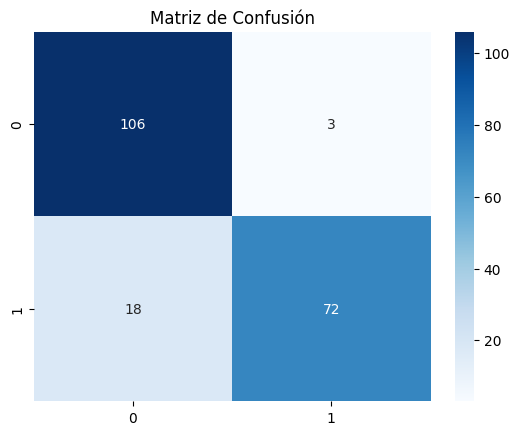

              precision    recall  f1-score   support

           0       0.85      0.97      0.91       109
           1       0.96      0.80      0.87        90

    accuracy                           0.89       199
   macro avg       0.91      0.89      0.89       199
weighted avg       0.90      0.89      0.89       199



In [37]:
# Predicciones y métricas
y_pred = (model.predict(X_test) > 0.5).astype(int)
print("Matriz de confusión:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.show()
print(classification_report(y_test, y_pred))


*   Alta tasa de verdaderos negativos (TN = 106): El modelo identifica correctamente la mayoría de los casos negativos.
*   Baja tasa de falsos positivos (FP = 3): El modelo casi nunca confunde negativos con positivos.
*   Moderada tasa de falsos negativos (FN = 18): El modelo omite una proporción significativa de casos positivos.
*   Buena tasa de verdaderos positivos (TP = 72): El modelo acierta en la mayoría de los casos positivos, pero no en todos.


Implicación clave: Aunque el modelo es muy preciso al identificar la clase 0, tiene dificultades para detectar todos los casos de la clase 1.

#### Clase 0:
* Precisión (0.85): El 85% de las veces que el modelo predice clase 0, acierta.

* Recall (0.97): El modelo detecta casi todos los casos reales de clase 0.

* F1-score (0.91): Excelente equilibrio entre precisión y recall.

#### Clase 1:
* Precisión (0.96): Muy alta, lo que indica que cuando el modelo predice clase 1, casi siempre es correcto.

* Recall (0.80): Más bajo, lo que significa que el modelo no detecta el 20% de los casos reales de clase 1.

* F1-score (0.87): Bueno, pero inferior al de la clase 0.

Implicación clave: El modelo es conservador al predecir la clase 1. Prefiere evitar falsos positivos, pero a costa de dejar pasar verdaderos positivos.

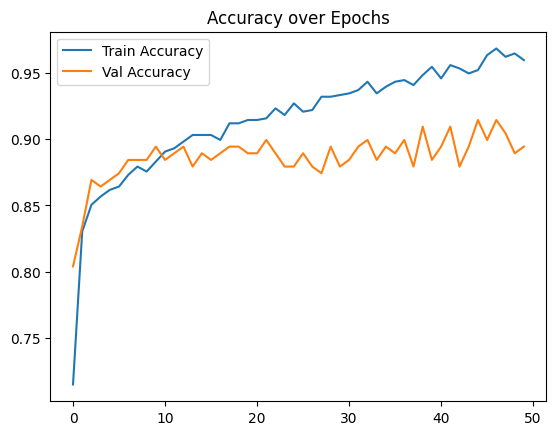

In [38]:
# Gráficos de loss y accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()
plt.show()


El gráfico de precisión por épocas muestra dos líneas:

* Precisión en entrenamiento: Aumenta consistentemente hasta superar 0.95.

* Precisión en validación: Fluctúa y se estabiliza cerca de 0.90.

Interpretación:
* El modelo aprende bien los datos de entrenamiento.

* Las fluctuaciones en validación indican que el modelo podría estar sobreajustando (overfitting), es decir, memorizando los datos en lugar de generalizar.

Implicación clave: Aunque el rendimiento en validación es alto, la diferencia con el entrenamiento sugiere que el modelo podría no comportarse igual de bien con datos nuevos o no vistos.

## Mejoras de desempeño

In [45]:
# Modelo mejorado

# Early Stopping
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model_improved = keras.Sequential([
    keras.layers.Dense(64, input_shape=(X_train.shape[1],)),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])

model_improved.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_improved = model_improved.fit(X_train, y_train, epochs=100, validation_split=0.2, callbacks=[early_stop], verbose=1)


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.5289 - loss: 0.8225 - val_accuracy: 0.5437 - val_loss: 0.6659
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6387 - loss: 0.6356 - val_accuracy: 0.7563 - val_loss: 0.5857
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7378 - loss: 0.5070 - val_accuracy: 0.7812 - val_loss: 0.5328
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7666 - loss: 0.4640 - val_accuracy: 0.7937 - val_loss: 0.4903
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7885 - loss: 0.4266 - val_accuracy: 0.8000 - val_loss: 0.4613
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8187 - loss: 0.4056 - val_accuracy: 0.8062 - val_loss: 0.4412
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7935 - loss: 0.4296 - val_accuracy: 0.8000 - val_loss: 0.4245
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8329 - loss: 0.3765 - val_accuracy: 0.7937 - val_loss: 0.

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8998 - loss: 0.2252 
Mejorado - Accuracy: 0.91, Loss: 0.22
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Matriz de confusión mejorada:


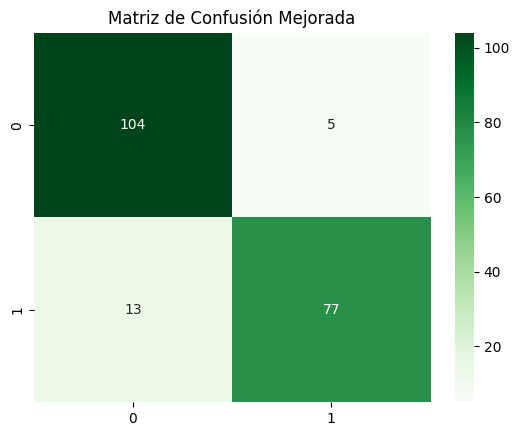

              precision    recall  f1-score   support

           0       0.89      0.95      0.92       109
           1       0.94      0.86      0.90        90

    accuracy                           0.91       199
   macro avg       0.91      0.90      0.91       199
weighted avg       0.91      0.91      0.91       199



In [48]:
# Evaluar mejorado
loss_imp, acc_imp = model_improved.evaluate(X_test, y_test)
print(f"Mejorado - Accuracy: {acc_imp:.2f}, Loss: {loss_imp:.2f}")
y_pred_imp = (model_improved.predict(X_test) > 0.5).astype(int)
print("Matriz de confusión mejorada:")
cm_imp = confusion_matrix(y_test, y_pred_imp)
sns.heatmap(cm_imp, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión Mejorada')
plt.show()
print(classification_report(y_test, y_pred_imp))

Tras la modificación en el modelo, se presentaron ciertas mejoras mínimas.

---

Falsos Negativos:
Disminuyen de 18 a 13, lo que representa una mejora significativa en la capacidad del modelo para detectar correctamente los casos positivos.


---


Falsos Positivos:

* Aumentan de 3 a 5, lo que indica que el modelo mejorado comete más errores al clasificar negativos como positivos.
* Aunque esto puede parecer una desventaja, es un trade-off aceptable si el objetivo es reducir los falsos negativos.
---
Verdaderos Positivos:
Aumentan de 72 a 77, lo que confirma que el modelo mejorado tiene mejor sensibilidad hacia la clase positiva.

---
Verdaderos Negativos:
Disminuyen ligeramente de 106 a 104, lo que refleja el pequeño aumento en falsos positivos.

#### Interpretación Estratégica
El modelo mejorado prioriza la detección de la clase positiva, lo cual puede ser deseable en contextos donde los falsos negativos son más costosos que los falsos positivos.

Aunque el número de falsos positivos aumentó, el balance general mejora, especialmente en términos de recall y verdaderos positivos.


# 🧾 Informe del Caso de Negocio  
### Predicción de Satisfacción Laboral mediante Redes Neuronales

---

## 📌 Contexto

La empresa busca fortalecer su estrategia de gestión humana mediante el uso de inteligencia artificial. Para ello, se desarrolló una red neuronal capaz de **predecir el nivel de satisfacción de los empleados**, con el fin de anticipar riesgos de rotación, mejorar el clima organizacional y tomar decisiones más informadas en políticas internas.

---

## 🎯 Objetivo

Construir un modelo predictivo que clasifique a los empleados como:

- **Clase 0:** Insatisfechos  
- **Clase 1:** Satisfechos  

El modelo se entrena utilizando variables como desempeño, antigüedad, carga laboral, evaluaciones internas, entre otras.

---

## ⚙️ Solución Técnica

Se implementó una red neuronal entrenada con datos históricos de empleados. El rendimiento del modelo fue evaluado mediante:

- Matriz de confusión  
- Métricas por clase (precisión, recall, F1-score)  
- Exactitud general  
- Pérdida (loss)

---

## 📈 Resultados Iniciales

- **Exactitud:** 89%  
- **Pérdida:** 0.21  
- **Falsos negativos (insatisfechos no detectados):** 18  
- **Verdaderos positivos (satisfechos detectados):** 72  
- **Falsos positivos:** 3  
- **Verdaderos negativos:** 106  

El modelo mostraba buen rendimiento general, pero tenía dificultades para identificar correctamente a los empleados insatisfechos, lo que representa un riesgo operativo.

---

## 🔧 Mejoras Aplicadas

Para mejorar el rendimiento del modelo, se aplicaron las siguientes técnicas:

- **Batch Normalization:** para estabilizar y acelerar el entrenamiento, reduciendo la sensibilidad a la inicialización de pesos.  
- **Dropout:** para prevenir el sobreajuste, eliminando aleatoriamente neuronas durante el entrenamiento.  
- **Early Stopping:** para detener el entrenamiento cuando el rendimiento en validación dejaba de mejorar, evitando sobreentrenamiento.

---

## 📊 Resultados Tras la Mejora

- **Exactitud:** 91%  
- **Pérdida:** 0.22  
- **Falsos negativos (insatisfechos no detectados):** 13  
- **Verdaderos positivos (satisfechos detectados):** 77  
- **Falsos positivos:** 5  
- **Verdaderos negativos:** 104  

📌 *Nota técnica:* Aunque la pérdida aumentó ligeramente, el modelo mejorado logra una mejor detección de empleados insatisfechos, lo cual es más relevante para los objetivos del negocio. Este tipo de compensación es común en modelos de clasificación.

---

## 💡 Impacto en el Negocio

El modelo mejorado permite:

- **Detectar proactivamente empleados insatisfechos**, facilitando intervenciones tempranas  
- **Reducir la rotación laboral y mejorar el clima organizacional**  
- **Optimizar recursos de gestión humana**, enfocándose en los perfiles con mayor riesgo  

---

## ⚠️ Limitaciones y Consideraciones

1. **Aumento en la pérdida:** La pérdida subió de 0.21 a 0.22, lo que indica una leve disminución en el ajuste del modelo.  
2. **Trade-off entre precisión y sensibilidad:** La mejora en recall de la clase insatisfecha vino acompañada de un aumento en falsos positivos.  
3. **Generalización:** Se requiere validación con datos nuevos para confirmar la robustez del modelo.  
4. **Interpretabilidad:** Las redes neuronales pueden ser difíciles de interpretar; se recomienda complementar con técnicas explicativas.

---

## ✅ Conclusión

La red neuronal ajustada representa una herramienta estratégica para la empresa, al permitir una **detección más precisa de la insatisfacción laboral**. Esto fortalece la toma de decisiones en talento humano y contribuye directamente a la retención y bienestar de los empleados.
